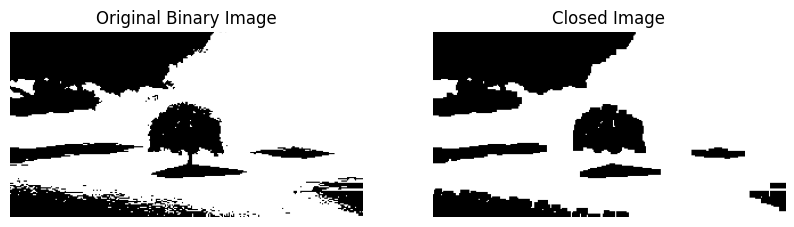

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image specified by the user
# Ensure the image path is correct, and the image exists in the environment
image_path = '/content/image 3.jpg'
loaded_image = cv2.imread(image_path)

if loaded_image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert the image to grayscale if it's a color image
    if len(loaded_image.shape) == 3:
        gray_image = cv2.cvtColor(loaded_image, cv2.COLOR_BGR2GRAY)
    else:
        gray_image = loaded_image

    # Apply a binary threshold to ensure it's a binary image for morphological operations
    # You might need to adjust the threshold value based on your image
    _, binary_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    # Define a kernel (structuring element)
    # A 5x5 rectangular kernel is commonly used
    kernel = np.ones((5, 5), np.uint8)

    # Perform the Closing operation
    # Closing is dilation followed by erosion
    # It helps to close small holes inside foreground objects and connects nearby objects.
    closed_image = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, kernel)

    # Display the original and closed images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(binary_image, cmap='gray')
    plt.title('Original Binary Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(closed_image, cmap='gray')
    plt.title('Closed Image')
    plt.axis('off')

    plt.show()
